# Plot Sternberg model firing rates

In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import lfp_utils as lu
import rate_neuron_utils as rn
from bootstrap_method import *

2026-04-23 14:53:27.239366: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 14:53:27.248573: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 14:53:27.257796: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 14:53:27.260511: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 14:53:27.267984: I tensorflow/core/platform/cpu_feature_guar

In [2]:
delay = 200
condn_phrase = 'delay'
condn_num = delay

# condn_key = f'{condn_phrase}{condn_num}'

In [7]:
# the two models with > 0.7 accuracy are:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_paths = ['Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat']

model_names = [os.path.basename(m)[:-4] for m in model_paths]

In [3]:
all_models_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_paths = ld.find_files(all_models_dir, '*N_1000*.mat')
model_names = [os.path.basename(m)[:-4] for m in model_paths]
print(len(model_names))
print(model_names)

7
['Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628', 'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058']


In [8]:
# find folder names within model directory

perfs = []
for i, model_name in enumerate(model_names):
    trial_labels, trial_perfs, _ = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num, 
                                                         all_models_dir=all_models_dir)
    load1_idx = np.where(trial_labels[:,0] == 1)[0]
    load3_idx = np.where(trial_labels[:,0] == 3)[0]
    perfs.append([np.mean(trial_perfs[load1_idx]), np.mean(trial_perfs[load3_idx])])
    print(f'Model {model_name}, performance: {perfs[i]}')


Model Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533, performance: [0.7083333333333334, 0.8055555555555556]
Model Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713, performance: [0.75, 0.7048611111111112]


In [9]:
# choose a model to visualize for now
model_name = model_names[0]
model_dir = os.path.join(all_models_dir, model_name)

# find files for this delay of interest
data_files = ld.find_files_keywords(model_dir, [f'delay{delay}'])
print(data_files)

['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533/settings_dict_delay200.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533/bhv_dict_delay200.pkl', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533/neural_dict_delay200.pkl']


## plot rates

In [10]:
# neural data
_, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num,
                                            all_models_dir = all_models_dir, load_LFP=False)

In [11]:
rates_data.shape # (num_trials, num_neurons, num_timepoints)

(336, 1000, 450)

In [12]:
settings = ld.load_settings_rate_data(model_name, condn_phrase, condn_num, all_models_dir=all_models_dir)
settings

{'T': 450,
 'stim_on': 50,
 'stim_dur': 25,
 'delay': 200,
 'DeltaT': 1,
 'taus': 20,
 'fs': 200,
 'task': 'sternberg',
 'load': 1}

In [13]:
# behavioral data
trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    all_models_dir=all_models_dir)

print(trial_labels.shape, trial_perfs.shape, trial_outputs.shape)

# trial_labels is (load, match/mismatch)

(336, 6) (336,) (336, 450)


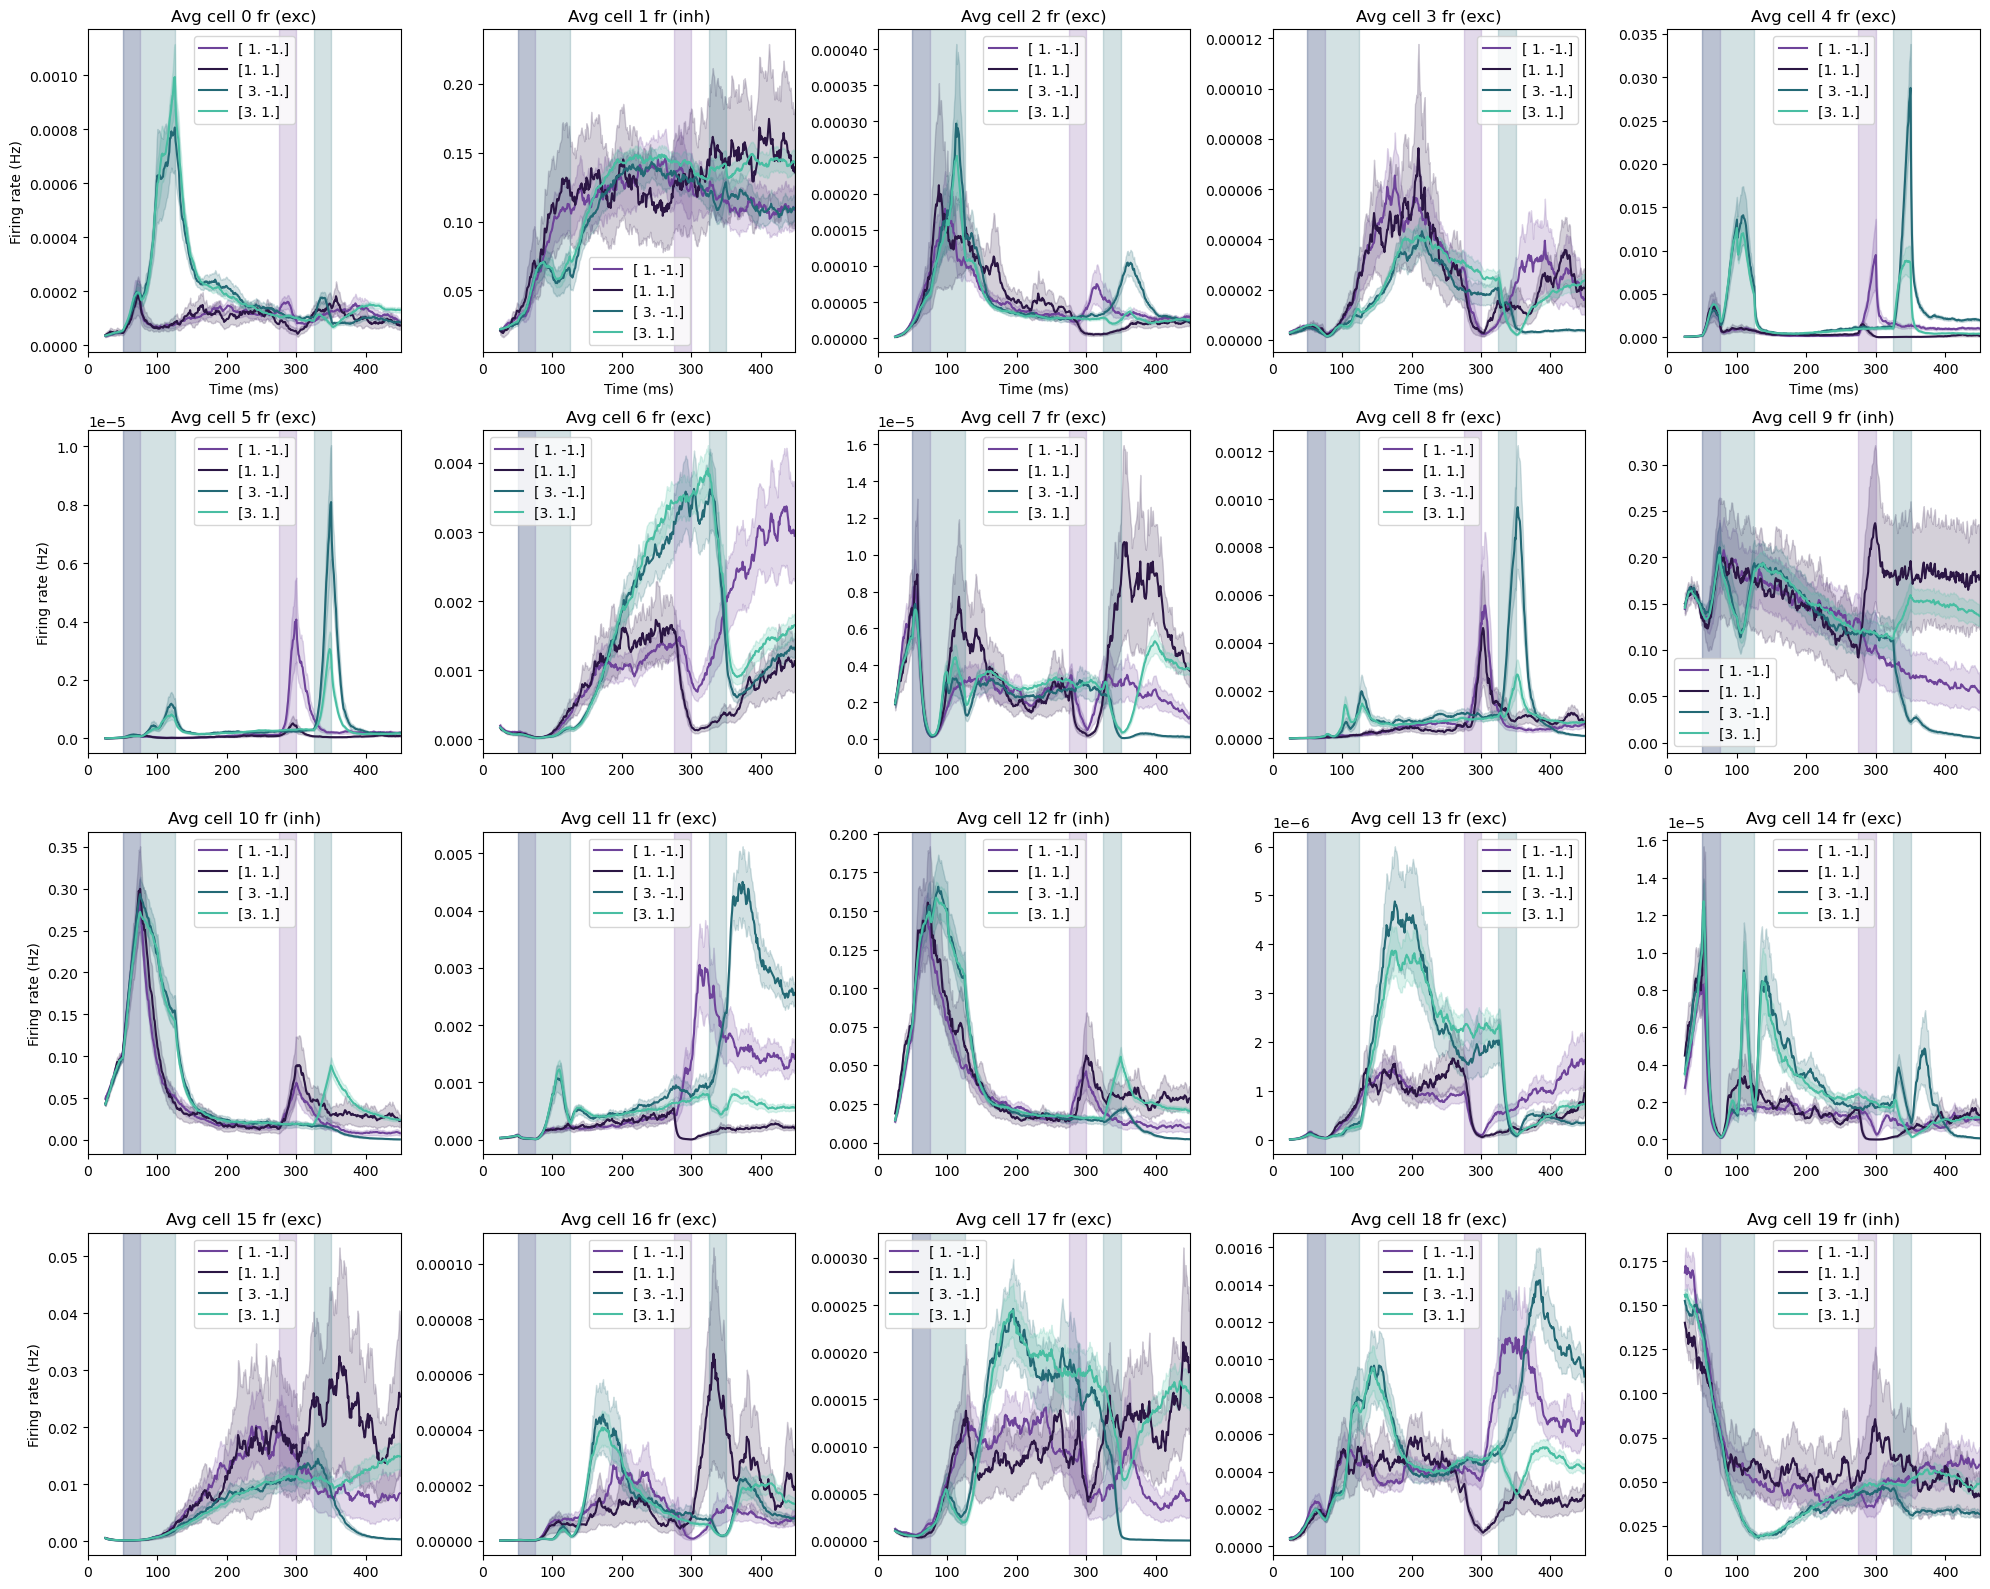

In [15]:
# let's take a look some neurons
import rate_neuron_utils as rn
importlib.reload(rn)

fig, axs = plt.subplots(4,5, figsize=(20,16))
axs = axs.flatten()
for n_neuron in range(20):
    rn.plot_neuron_rates(model_name, n_neuron, condn_phrase, condn_num, rates_data = rates_data, 
                         cut_off=25, ax=axs[n_neuron],
                         all_models_dir=all_models_dir)
    # axs[n_neuron].set_title(f'Neuron {n_neuron}')

# remove axis labels besides the first row and first column
for i in range(4):
    for j in range(5):
        if i > 0:
            axs[i*5 + j].set_xlabel('')
        if j > 0:
            axs[i*5 + j].set_ylabel('')
        
plt.tight_layout()
plt.show()

## population activity

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
neuron_rates_pca = pca.fit_transform(rates_data[0, :, :]) # (num_neurons, num_timepoints) -> (num_neurons, 2)
sort_idx = np.argsort(neuron_rates_pca[:,0])

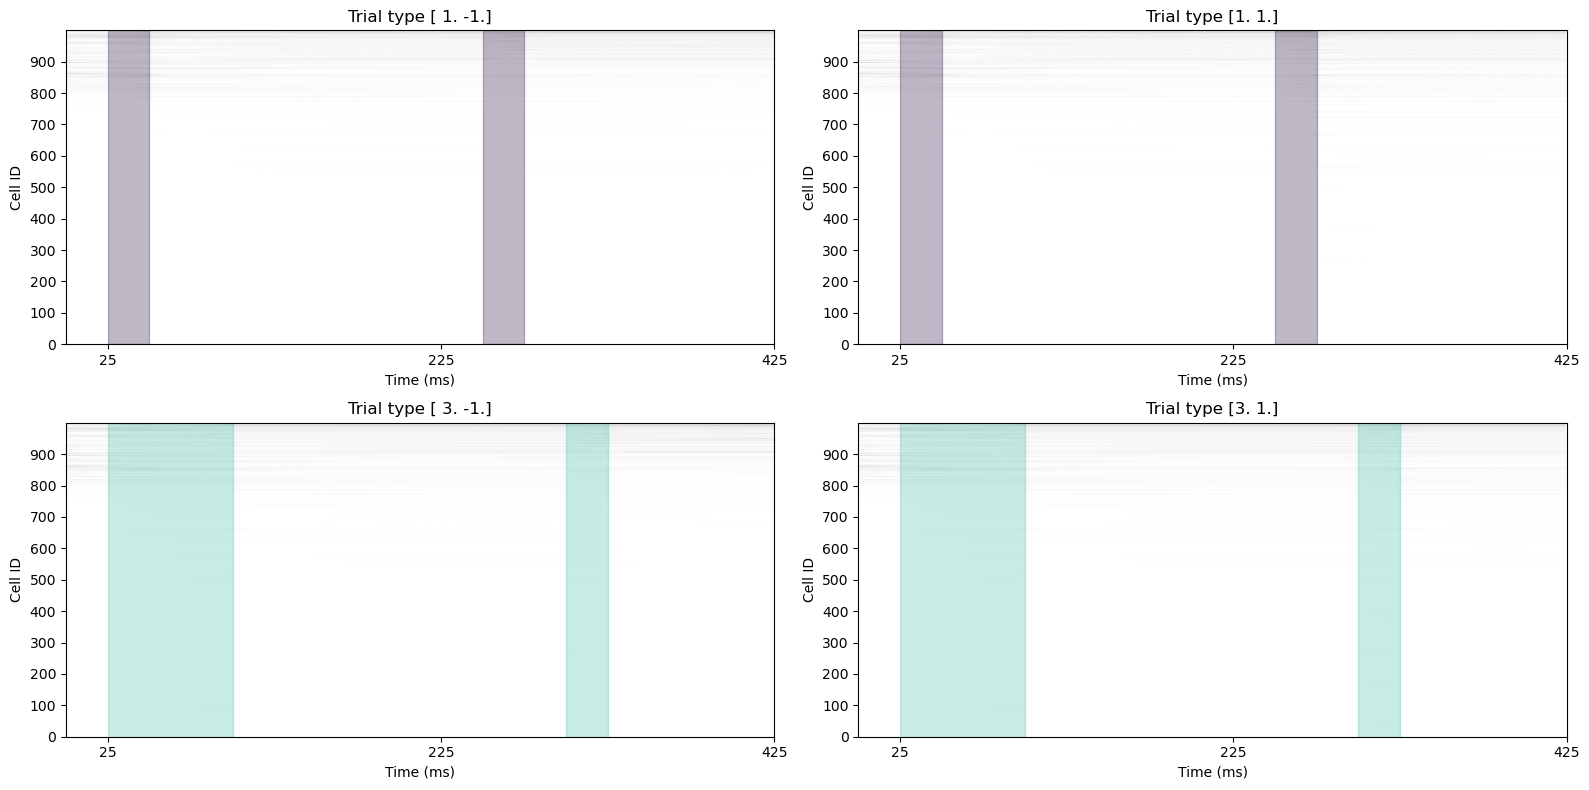

In [19]:
importlib.reload(rn)

rn.plot_trialtype_meanrates(model_name, condn_phrase, condn_num, 
                            rates_data = rates_data, sort=sort_idx,
                            cut_off=25, hlines=[], normalize=False,
                            all_models_dir=all_models_dir,
                            vmin=0, vmax=1, cmap='Greys')

In [20]:
exc_ind, inh_ind = ld.get_celltype_label(model_name, all_models_dir=all_models_dir)
# exc_bool = np.zeros(rates_data.shape[1], dtype=bool)
# exc_bool[exc_ind] = True
# inh_bool = np.zeros(rates_data.shape[1], dtype=bool)
# inh_bool[inh_ind] = True

/tmp/ipykernel_633081/332100195.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([sort_idx[exc_ind], sort_idx[inh_ind]], labels=['Excitatory', 'Inhibitory'])


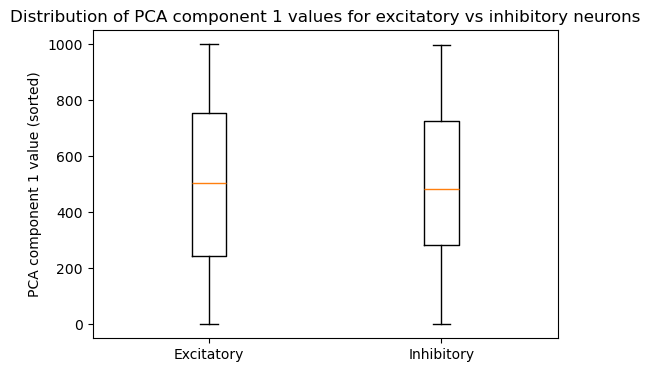

In [21]:
plt.figure(figsize=(6,4))
plt.boxplot([sort_idx[exc_ind], sort_idx[inh_ind]], labels=['Excitatory', 'Inhibitory'])
plt.ylabel('PCA component 1 value (sorted)')
plt.title('Distribution of PCA component 1 values for excitatory vs inhibitory neurons')
plt.show()

In [22]:
# small test

trial_types, trial_idxs = np.unique(trial_labels[:,:2], axis=0, return_inverse=True)
trial_pcs = []

pca = PCA(n_components=3).fit(rates_data[0, :, 25:].T) # fit PCA on all neurons' rates across time (after cut-off)
for i, trial_type in enumerate(trial_types):
    trial_mean_rate = np.mean(rates_data[trial_idxs == i, :, 25:], axis=0) # (num_neurons, num_timepoints)
    trial_pc = pca.transform(trial_mean_rate.T) # (num_timepoints, num_neurons) -> (num_timepoints, 3)
    trial_pcs.append(trial_pc)


In [23]:
trial_pcs[0].shape

(425, 3)

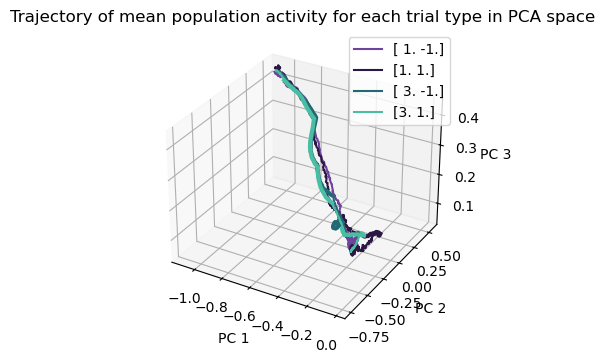

In [25]:
from mpl_toolkits.mplot3d import axes3d
%matplotlib inline 
# %matplotlib widget

_, colors = rn.get_trialtype_colors()
ax = plt.figure(figsize=(6,4)).add_subplot(projection='3d')
for i, trial_type in enumerate(trial_types):
    ax.plot(trial_pcs[i][:,0], trial_pcs[i][:,1], trial_pcs[i][:,2], 
            label=f'{trial_type}', color=colors[i])
    load = int(trial_type[0])
    ax.plot(trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 0],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 1],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 2],
            color=colors[i], linewidth=3)
    ax.plot(trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 0],
            trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 1],
            trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 2],
            color=colors[i], linewidth=3)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Trajectory of mean population activity for each trial type in PCA space')
ax.legend()
plt.show()

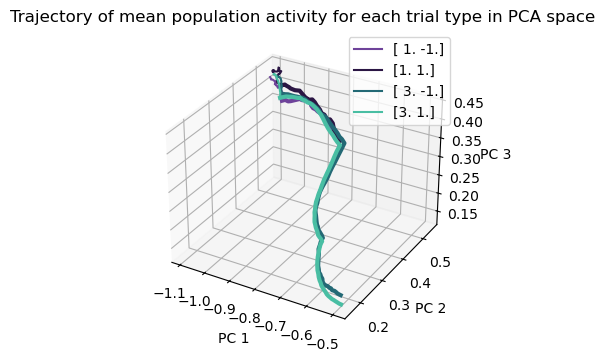

In [26]:
from mpl_toolkits.mplot3d import axes3d
%matplotlib inline 
# %matplotlib widget

_, colors = rn.get_trialtype_colors()
ax = plt.figure(figsize=(6,4)).add_subplot(projection='3d')
for i, trial_type in enumerate(trial_types):
    load = int(trial_type[0])
    delay_start = int(settings['stim_on'] + settings['stim_dur']*load - 25)
    ax.plot(trial_pcs[i][:delay_start,0], trial_pcs[i][:delay_start,1], trial_pcs[i][:delay_start,2], 
            label=f'{trial_type}', color=colors[i])
    ax.plot(trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 0],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 1],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 2],
            color=colors[i], linewidth=3)
    # ax.plot(trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 0],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 1],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 2],
    #         color=colors[i], linewidth=3)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Trajectory of mean population activity for each trial type in PCA space')
ax.legend()
plt.show()

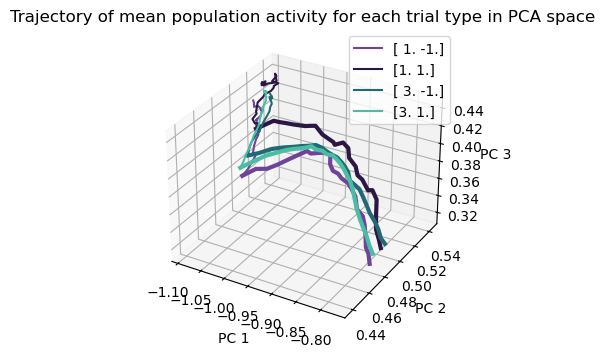

In [27]:
from mpl_toolkits.mplot3d import axes3d
%matplotlib inline 
# %matplotlib widget

_, colors = rn.get_trialtype_colors()
ax = plt.figure(figsize=(6,4)).add_subplot(projection='3d')

delay_start = int(settings['stim_on'] + settings['stim_dur']*1 - 25)
for i, trial_type in enumerate(trial_types):
    load = 1
    ax.plot(trial_pcs[i][:delay_start,0], trial_pcs[i][:delay_start,1], trial_pcs[i][:delay_start,2], 
            label=f'{trial_type}', color=colors[i])
    ax.plot(trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 0],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 1],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 2],
            color=colors[i], linewidth=3)
    # ax.plot(trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 0],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 1],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 2],
    #         color=colors[i], linewidth=3)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Trajectory of mean population activity for each trial type in PCA space')
ax.legend()
plt.show()

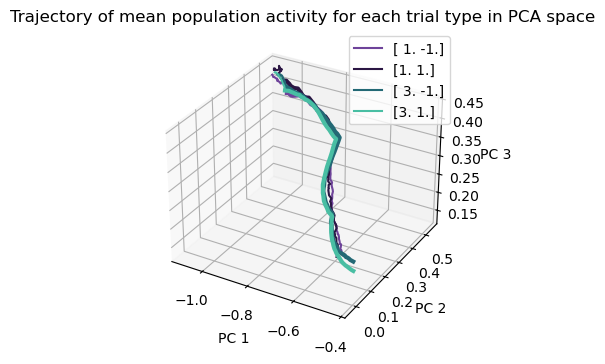

In [29]:
from mpl_toolkits.mplot3d import axes3d
%matplotlib inline 
# %matplotlib widget

_, colors = rn.get_trialtype_colors()
ax = plt.figure(figsize=(6,4)).add_subplot(projection='3d')

delay_start = int(settings['stim_on'] + settings['stim_dur']*3 - 25)
for i, trial_type in enumerate(trial_types):
    load = int(trial_type[0])
    ax.plot(trial_pcs[i][:delay_start,0], trial_pcs[i][:delay_start,1], trial_pcs[i][:delay_start,2], 
            label=f'{trial_type}', color=colors[i])
    ax.plot(trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 0],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 1],
            trial_pcs[i][settings['stim_on'] - 25:settings['stim_on'] + settings['stim_dur']*load - 25, 2],
            color=colors[i], linewidth=3)
    # ax.plot(trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 0],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 1],
    #         trial_pcs[i][settings['stim_on'] + settings['stim_dur']*load + settings['delay'] - 25:settings['stim_on'] + settings['stim_dur']*load + settings['delay'] + settings['stim_dur']- 25, 2],
    #         color=colors[i], linewidth=3)
    
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.set_title('Trajectory of mean population activity for each trial type in PCA space')
ax.legend()
plt.show()

PCA explained variance: [0.62352329 0.14931294 0.09015581], total: 0.8629920414839788
PCA explained variance: [0.67682926 0.09379947 0.05078508], total: 0.8214138081489362
PCA explained variance: [0.63312438 0.15097082 0.08765884], total: 0.8717540355221003


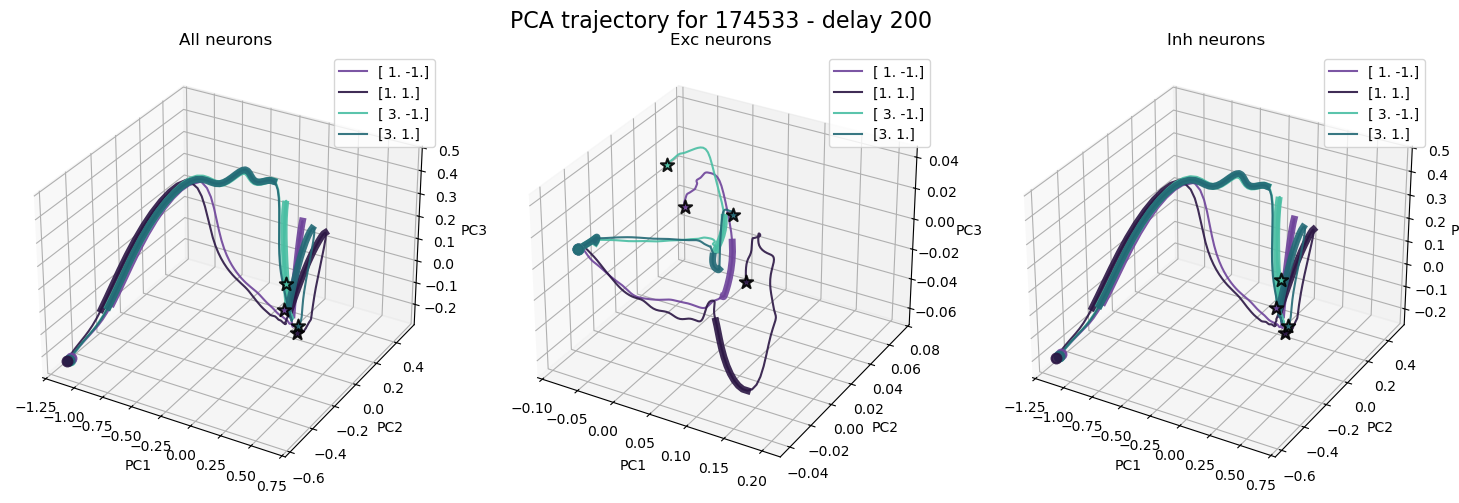

In [32]:
import population_utils as pu
importlib.reload(pu)
importlib.reload(ld)

# make 3d plot with 3 subplots
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132, projection='3d')
ax3 = fig.add_subplot(133, projection='3d')
_, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   neuron_ids=None, rates_data=rates_data, cut_off=25, 
                   ds=2, sigma=5, ax=ax1, title='All neurons',
                   all_models_dir=all_models_dir)
_, pca_exc = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   neuron_ids=exc_ind, rates_data=rates_data, cut_off=25, 
                   ds=2, sigma=5, ax=ax2, title='Exc neurons',
                   all_models_dir=all_models_dir)
_, pca_inh = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                   neuron_ids=inh_ind, rates_data=rates_data, cut_off=25,
                   ds=2, sigma=5, ax=ax3, title='Inh neurons',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {200}', fontsize=16)
plt.tight_layout()
plt.show()

In [33]:
rates_corr = rates_data[trial_perfs == 1,:,:]
rates_incorr = rates_data[trial_perfs == 0,:,:]

trials_labels_corr = trial_labels[trial_perfs == 1]
trials_labels_incorr = trial_labels[trial_perfs == 0]

Accuracy for 174533: 0.7916666666666666
PCA explained variance: [0.62352329 0.14931294 0.09015581], total: 0.8629920414839788
PCA explained variance: [0.62352329 0.14931294 0.09015581], total: 0.8629920414839788


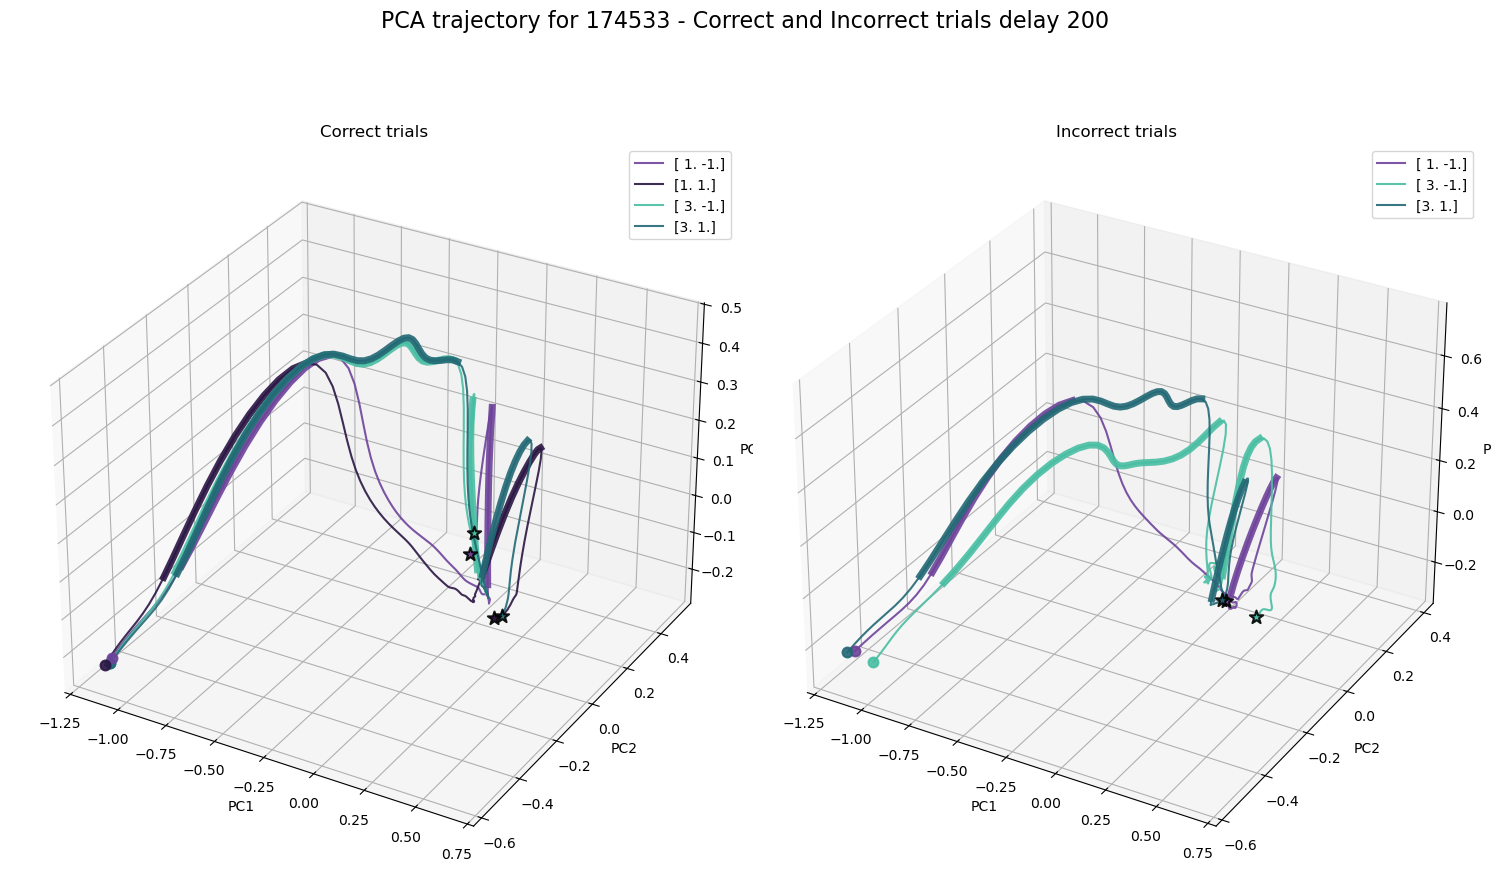

In [34]:
# plot correct and incorrect next to each other

print(f'Accuracy for {model_name[-6:]}: {trial_perfs.mean()}')

fig = plt.figure(figsize=(15, 10))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, 
                   ds=2, sigma=5,
                   cut_off=25, ax=ax1, title='Correct trials',
                   all_models_dir=all_models_dir)
pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200, pca_obj = pca_all,
                   neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, 
                   ds=2, sigma=5,
                   cut_off=25, ax=ax2, title='Incorrect trials',
                   all_models_dir=all_models_dir)
plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Correct and Incorrect trials {condn_phrase} {200}', fontsize=16)
plt.tight_layout()
plt.show()##

PCA explained variance: [0.62352329 0.14931294 0.09015581], total: 0.8629920414839791
PCA explained variance: [0.67682926 0.09379947 0.05078508], total: 0.8214138081489367
PCA explained variance: [0.63312438 0.15097082 0.08765884], total: 0.8717540355221007


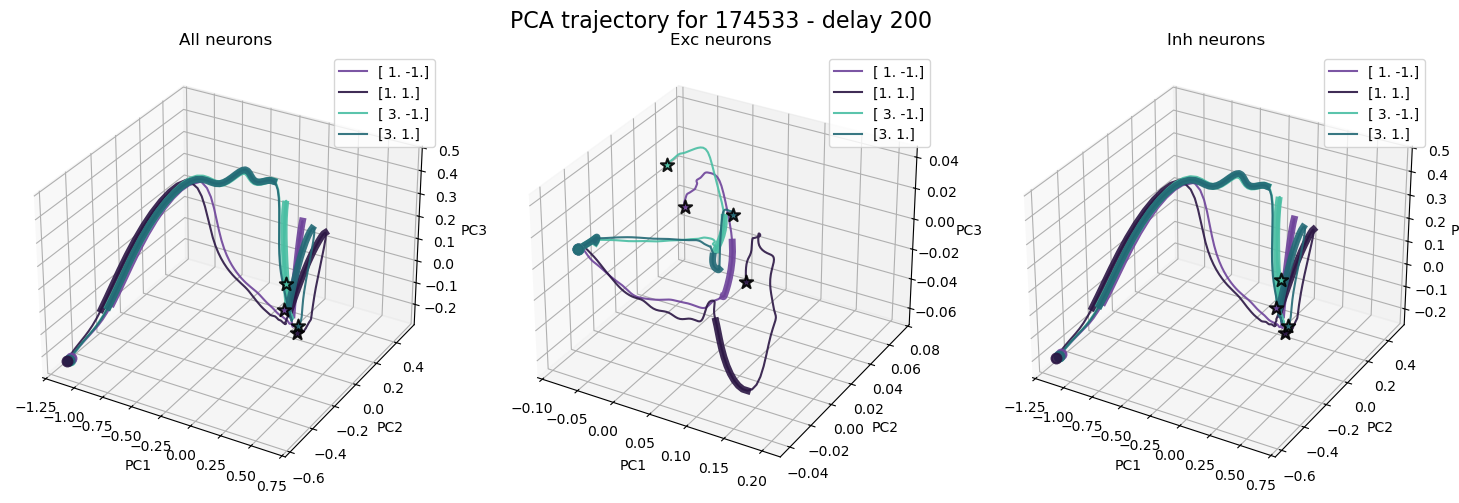

Accuracy for 174533: 0.7916666666666666
PCA explained variance: [0.62352329 0.14931294 0.09015581], total: 0.8629920414839791
PCA explained variance: [0.62352329 0.14931294 0.09015581], total: 0.8629920414839791


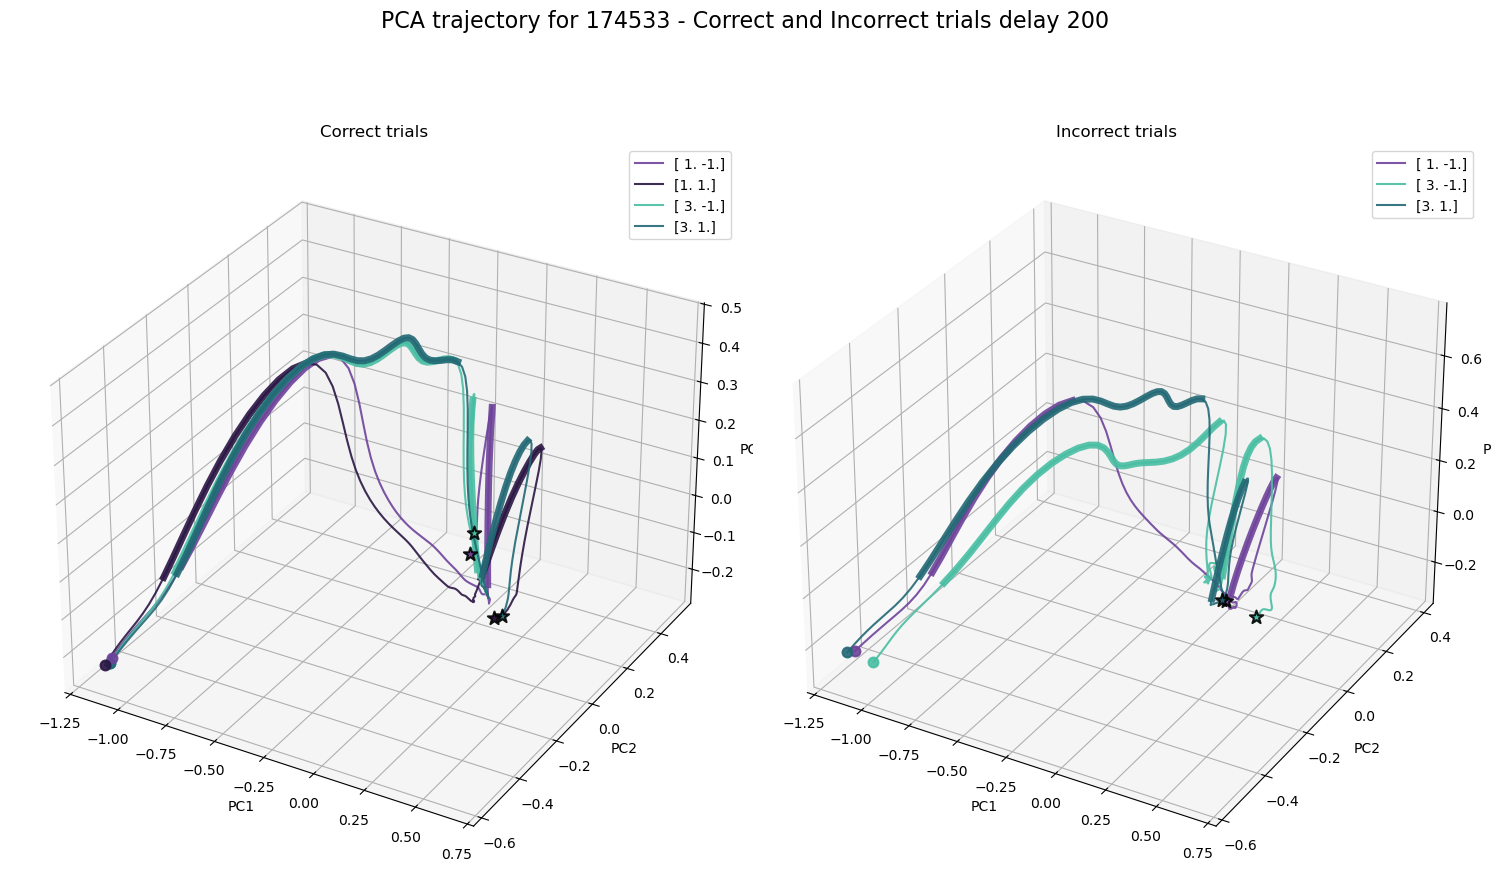

PCA explained variance: [0.57795342 0.16176929 0.11259526], total: 0.8523179688934295
PCA explained variance: [0.59766018 0.16699521 0.10515024], total: 0.8698056361135919
PCA explained variance: [0.51836891 0.16696507 0.13157582], total: 0.8169098054562698


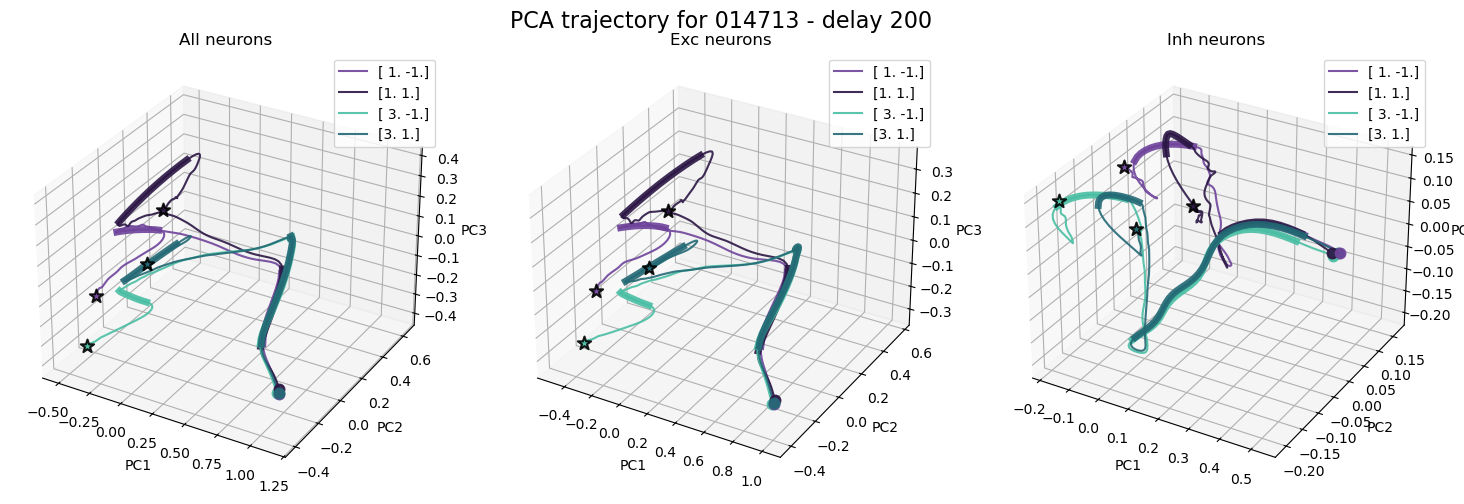

Accuracy for 014713: 0.7916666666666666
PCA explained variance: [0.57795342 0.16176929 0.11259526], total: 0.8523179688934295
PCA explained variance: [0.57795342 0.16176929 0.11259526], total: 0.8523179688934295


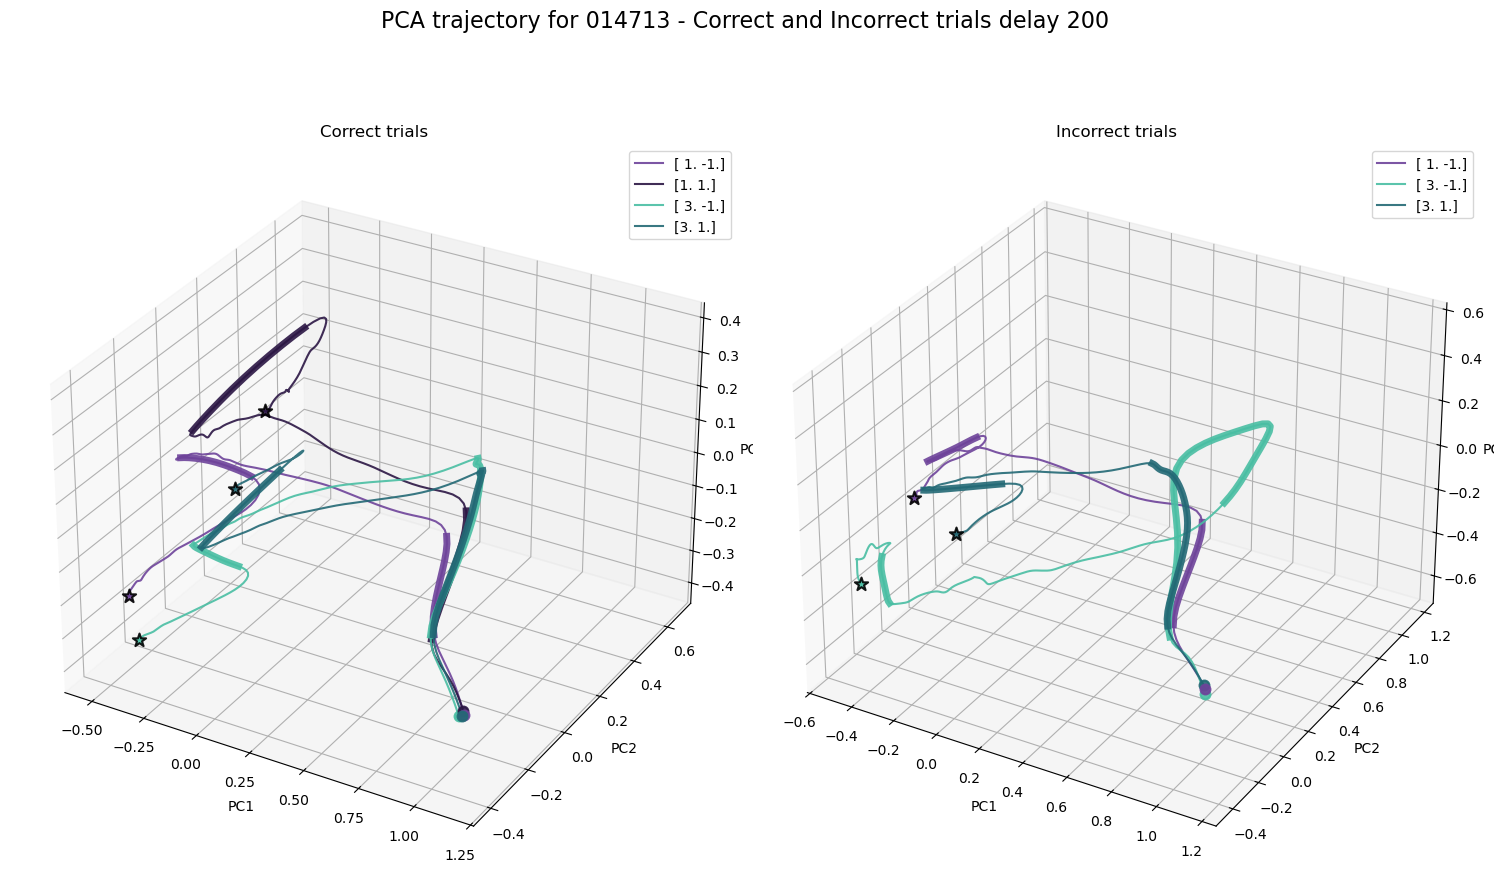

In [35]:
# across models

for i, model_name in enumerate(model_names):
    _, rates_data = ld.load_neural_rate_data(model_name, condn_phrase, condn_num,
                                            all_models_dir = all_models_dir, load_LFP=False)
    
    fig = plt.figure(figsize=(15, 5))
    ax1 = fig.add_subplot(131, projection='3d')
    ax2 = fig.add_subplot(132, projection='3d')
    ax3 = fig.add_subplot(133, projection='3d')
    _, pca_all = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                    neuron_ids=None, rates_data=rates_data, cut_off=25, 
                    ds=2, sigma=5, ax=ax1, title='All neurons',
                    all_models_dir=all_models_dir)
    _, pca_exc = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                    neuron_ids=exc_ind, rates_data=rates_data, cut_off=25, 
                    ds=2, sigma=5, ax=ax2, title='Exc neurons',
                    all_models_dir=all_models_dir)
    _, pca_inh = pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200,
                    neuron_ids=inh_ind, rates_data=rates_data, cut_off=25,
                    ds=2, sigma=5, ax=ax3, title='Inh neurons',
                    all_models_dir=all_models_dir)
    plt.suptitle(f'PCA trajectory for {model_name[-6:]} - {condn_phrase} {200}', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    rates_corr = rates_data[trial_perfs == 1,:,:]
    rates_incorr = rates_data[trial_perfs == 0,:,:]

    trials_labels_corr = trial_labels[trial_perfs == 1]
    trials_labels_incorr = trial_labels[trial_perfs == 0]
    
    # plot correct and incorrect next to each other

    print(f'Accuracy for {model_name[-6:]}: {trial_perfs.mean()}')

    fig = plt.figure(figsize=(15, 10))
    ax1 = fig.add_subplot(121, projection='3d')
    ax2 = fig.add_subplot(122, projection='3d')

    pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200, pca_obj = pca_all,
                    neuron_ids=None, rates_data=rates_corr, trial_labels=trials_labels_corr, 
                    ds=2, sigma=5,
                    cut_off=25, ax=ax1, title='Correct trials',
                    all_models_dir=all_models_dir)
    pu.plot_trajectory_pca(model_name, condn_phrase='delay', condn_num=200, pca_obj = pca_all,
                    neuron_ids=None, rates_data=rates_incorr, trial_labels=trials_labels_incorr, 
                    ds=2, sigma=5,
                    cut_off=25, ax=ax2, title='Incorrect trials',
                    all_models_dir=all_models_dir)
    plt.suptitle(f'PCA trajectory for {model_name[-6:]} - Correct and Incorrect trials {condn_phrase} {200}', fontsize=16)
    plt.tight_layout()
    plt.show()##